# 🐍 Snake Game with Reinforcement Learning (DQN)

Training a snake to eat food using Deep Q-Networks. The agent learns through trial and error, starting completely random and gradually improving.

## 1. Imports & Setup

In [2]:
import pygame
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
from collections import deque, namedtuple
from enum import Enum
import matplotlib.pyplot as plt
from IPython import display

plt.ion()
print('All imports ready')

All imports ready


## 2. Constants

In [4]:
BLOCK_SIZE = 20
WIDTH, HEIGHT = 640, 480

LR = 0.001
BATCH_SIZE = 64
MEMORY_SIZE = 100_000
GAMMA = 0.9
EPS_START = 1.0
EPS_END = 0.01
EPS_DECAY = 0.995

WHITE = (255, 255, 255)
RED = (200, 0, 0)
BLUE1 = (0, 0, 255)
BLUE2 = (0, 100, 255)
BLACK = (0, 0, 0)

## 3. Game Environment

The snake moves on a grid. State = 11 values:
- **3** danger booleans (straight/right/left)
- **4** direction one-hot
- **4** food position relative to head

Actions: `[1,0,0]` = straight, `[0,1,0]` = turn right, `[0,0,1]` = turn left

Rewards: +10 for food, -10 for death, 0 otherwise

In [5]:
class Direction(Enum):
    RIGHT = 1
    LEFT = 2
    UP = 3
    DOWN = 4

Point = namedtuple('Point', 'x, y')


class SnakeGame:
    def __init__(self, w=WIDTH, h=HEIGHT):
        self.w = w
        self.h = h
        self.reset()

    def reset(self):
        self.direction = Direction.RIGHT
        self.head = Point(self.w // 2, self.h // 2)
        self.snake = [
            self.head,
            Point(self.head.x - BLOCK_SIZE, self.head.y),
            Point(self.head.x - 2 * BLOCK_SIZE, self.head.y),
        ]
        self.score = 0
        self.food = None
        self._place_food()
        self.frame_iteration = 0

    def _place_food(self):
        x = random.randint(0, (self.w - BLOCK_SIZE) // BLOCK_SIZE) * BLOCK_SIZE
        y = random.randint(0, (self.h - BLOCK_SIZE) // BLOCK_SIZE) * BLOCK_SIZE
        self.food = Point(x, y)
        if self.food in self.snake:
            self._place_food()

    def _is_collision(self, pt=None):
        if pt is None:
            pt = self.head
        if pt.x < 0 or pt.x >= self.w or pt.y < 0 or pt.y >= self.h:
            return True
        return pt in self.snake[1:]

    def play_step(self, action):
        self.frame_iteration += 1
        self._move(action)
        self.snake.insert(0, self.head)

        reward = 0
        game_over = False

        if self._is_collision() or self.frame_iteration > 100 * len(self.snake):
            game_over = True
            reward = -10
            return reward, game_over, self.score

        if self.head == self.food:
            self.score += 1
            reward = 10
            self._place_food()
        else:
            self.snake.pop()

        return reward, game_over, self.score

    def _move(self, action):
        clock_wise = [Direction.RIGHT, Direction.DOWN, Direction.LEFT, Direction.UP]
        idx = clock_wise.index(self.direction)
        if np.array_equal(action, [1, 0, 0]):
            new_dir = clock_wise[idx]
        elif np.array_equal(action, [0, 1, 0]):
            new_dir = clock_wise[(idx + 1) % 4]
        else:
            new_dir = clock_wise[(idx - 1) % 4]
        self.direction = new_dir

        x, y = self.head.x, self.head.y
        if self.direction == Direction.RIGHT:
            x += BLOCK_SIZE
        elif self.direction == Direction.LEFT:
            x -= BLOCK_SIZE
        elif self.direction == Direction.DOWN:
            y += BLOCK_SIZE
        elif self.direction == Direction.UP:
            y -= BLOCK_SIZE
        self.head = Point(x, y)

    def get_state(self):
        head = self.head
        pl = Point(head.x - BLOCK_SIZE, head.y)
        pr = Point(head.x + BLOCK_SIZE, head.y)
        pu = Point(head.x, head.y - BLOCK_SIZE)
        pd = Point(head.x, head.y + BLOCK_SIZE)

        d = self.direction
        dir_l = d == Direction.LEFT
        dir_r = d == Direction.RIGHT
        dir_u = d == Direction.UP
        dir_d = d == Direction.DOWN

        return np.array([
            (dir_r and self._is_collision(pr)) or (dir_l and self._is_collision(pl)) or
            (dir_u and self._is_collision(pu)) or (dir_d and self._is_collision(pd)),
            (dir_u and self._is_collision(pr)) or (dir_d and self._is_collision(pl)) or
            (dir_l and self._is_collision(pu)) or (dir_r and self._is_collision(pd)),
            (dir_d and self._is_collision(pr)) or (dir_u and self._is_collision(pl)) or
            (dir_r and self._is_collision(pu)) or (dir_l and self._is_collision(pd)),
            dir_l, dir_r, dir_u, dir_d,
            self.food.x < self.head.x,
            self.food.x > self.head.x,
            self.food.y < self.head.y,
            self.food.y > self.head.y,
        ], dtype=int)

print('SnakeGame ready')

SnakeGame ready


## 4. Deep Q-Network & Agent

In [6]:
class LinearQNet(nn.Module):
    def __init__(self, input_size=11, hidden_size=256, output_size=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size),
        )

    def forward(self, x):
        return self.net(x)


class QTrainer:
    def __init__(self, model, lr=LR, gamma=GAMMA):
        self.model = model
        self.gamma = gamma
        self.optimizer = optim.Adam(model.parameters(), lr=lr)
        self.criterion = nn.MSELoss()

    def train_step(self, state, action, reward, next_state, done):
        state = torch.tensor(np.array(state), dtype=torch.float)
        next_state = torch.tensor(np.array(next_state), dtype=torch.float)
        action = torch.tensor(np.array(action), dtype=torch.long)
        reward = torch.tensor(np.array(reward), dtype=torch.float)

        if len(state.shape) == 1:
            state = state.unsqueeze(0)
            next_state = next_state.unsqueeze(0)
            action = action.unsqueeze(0)
            reward = reward.unsqueeze(0)
            done = (done,)

        pred = self.model(state)
        target = pred.clone()

        for i in range(len(done)):
            q = reward[i]
            if not done[i]:
                q = reward[i] + self.gamma * self.model(next_state[i]).max()
            target[i][action[i].argmax().item()] = q

        self.optimizer.zero_grad()
        self.criterion(target, pred).backward()
        self.optimizer.step()


class Agent:
    def __init__(self):
        self.n_games = 0
        self.epsilon = EPS_START
        self.memory = deque(maxlen=MEMORY_SIZE)
        self.model = LinearQNet()
        self.trainer = QTrainer(self.model)

    def get_action(self, state):
        if random.random() < self.epsilon:
            move = random.randint(0, 2)
        else:
            with torch.no_grad():
                move = self.model(torch.tensor(state, dtype=torch.float)).argmax().item()
        final = [0, 0, 0]
        final[move] = 1
        return final

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def train_long_memory(self):
        sample = self.memory if len(self.memory) < BATCH_SIZE else random.sample(self.memory, BATCH_SIZE)
        self.trainer.train_step(*zip(*sample))

    def train_short_memory(self, state, action, reward, next_state, done):
        self.trainer.train_step(state, action, reward, next_state, done)

print('DQN Agent ready')

DQN Agent ready


## 5. Training Loop

Let's train the agent! The plot updates in real-time showing score per game and the running mean.

<Figure size 640x480 with 0 Axes>

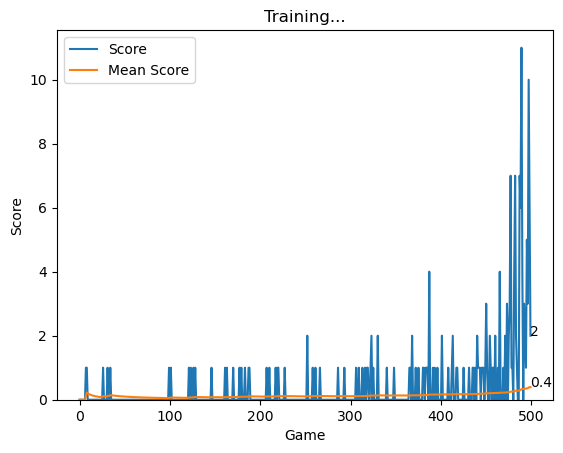


Done! Record: 11 | Final Mean: 0.4


In [7]:
def plot(scores, mean_scores):
    display.clear_output(wait=True)
    display.display(plt.gcf())
    plt.clf()
    plt.title('Training...')
    plt.xlabel('Game')
    plt.ylabel('Score')
    plt.plot(scores, label='Score')
    plt.plot(mean_scores, label='Mean Score')
    plt.ylim(ymin=0)
    plt.text(len(scores) - 1, scores[-1], str(scores[-1]))
    plt.text(len(mean_scores) - 1, mean_scores[-1], f'{mean_scores[-1]:.1f}')
    plt.legend()
    plt.show(block=False)
    plt.pause(0.001)


agent = Agent()
game = SnakeGame()

scores = []
mean_scores = []
record = 0
total = 0
NUM_GAMES = 500

for _ in range(NUM_GAMES):
    state_old = game.get_state()
    while True:
        action = agent.get_action(state_old)
        reward, done, score = game.play_step(action)
        state_new = game.get_state()
        agent.train_short_memory(state_old, action, reward, state_new, done)
        agent.remember(state_old, action, reward, state_new, done)
        if done:
            break
        state_old = state_new

    game.reset()
    agent.n_games += 1
    agent.train_long_memory()

    if score > record:
        record = score

    scores.append(score)
    total += score
    mean_scores.append(total / agent.n_games)
    agent.epsilon = max(EPS_END, agent.epsilon * EPS_DECAY)

    if agent.n_games % 50 == 0:
        plot(scores, mean_scores)

plot(scores, mean_scores)
print(f'\nDone! Record: {record} | Final Mean: {total/NUM_GAMES:.1f}')

## 6. Watch the Trained Agent

Run this cell to see the agent play. A Pygame window will open.

In [8]:
agent.epsilon = 0
game_w = SnakeGame()

try:
    pygame.init()
    display_surface = pygame.display.set_mode((WIDTH, HEIGHT))
    pygame.display.set_caption('Trained Snake')
    clock = pygame.time.Clock()
    font = pygame.font.SysFont('arial', 25)

    # Draw helper
    def draw_game(snake, food, score):
        display_surface.fill(BLACK)
        for pt in snake:
            pygame.draw.rect(display_surface, BLUE1, (*pt, BLOCK_SIZE, BLOCK_SIZE))
            pygame.draw.rect(display_surface, BLUE2, (pt.x + 4, pt.y + 4, 12, 12))
        pygame.draw.rect(display_surface, RED, (*food, BLOCK_SIZE, BLOCK_SIZE))
        display_surface.blit(font.render(f'Score: {score}', True, WHITE), (0, 0))
        pygame.display.flip()

    running = True
    while running:
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                running = False

        state = game_w.get_state()
        action = agent.get_action(state)
        _, done, score = game_w.play_step(action)
        draw_game(game_w.snake, game_w.food, score)
        clock.tick(10)

        if done:
            print(f'Died with score: {score}')
            game_w.reset()

finally:
    pygame.quit()

/home/erick-lamboe/anaconda3/lib/python3.13/site-packages/pygame/sysfont.py:226: UserWarning: Process running 'fc-list' timed-out! System fonts cannot be loaded on your platform
  warnings.warn(


Died with score: 21
Died with score: 13
Died with score: 27
Died with score: 18
Died with score: 14
Died with score: 25
Died with score: 21
Died with score: 28
Died with score: 14
